 **LAB EXPERIMENT - 4\
   Probabilistic Classification using Naïve Bayes
                    (Gaussian & Multinomial Naïve Bayes)**

Name       : Priya Dharshini R \
Roll No    : 24BAD092



**SCENARIO 1 – MULTINOMIAL NAÏVE BAYES**

Problem Statement
Classify SMS messages as Spam or Ham (Not Spam).

Dataset (Kaggle – Public)\
https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

Target Variable:
Message Label (Spam / Ham)

Input Feature:
SMS Text Messages

**IN-LAB TASKS**

1. Import required Python libraries.

2. Load the SMS Spam dataset.

3. Perform data preprocessing:
   • Text cleaning (lowercase, punctuation removal)
   • Stopword removal

4. Convert text into numerical features using:
   • Count Vectorization

5. Encode target labels.

6. Split dataset into training and testing sets.

7. Train Multinomial Naïve Bayes classifier.

8. Predict message classes.

9. Evaluate performance using:
   • Accuracy
   • Precision
   • Recall
   • F1 Score

10. Analyze misclassified examples.

11. Apply Laplace smoothing and observe impact.


**Visualizations**

• Confusion Matrix

• Feature Importance
  (Top words influencing spam classification)

• Word Frequency Comparison
  (Spam vs Ham)

SCENARIO 1 – MULTINOMIAL NAÏVE BAYES
Name    : Priya Dharshini R
Roll No : 24BAD092

Dataset Loaded Successfully
Dataset Shape: (5572, 2)

Class Distribution:
 label
ham     4825
spam     747
Name: count, dtype: int64

MODEL PERFORMANCE
Accuracy : 0.9704035874439462
Precision: 0.8625
Recall   : 0.9261744966442953
F1 Score : 0.8932038834951457


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


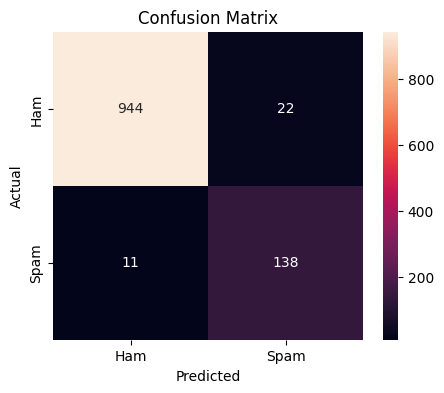


Sample Misclassified Messages:
     label                                            message
5     spam  FreeMsg Hey there darling it's been 3 week's n...
3979  spam                                 ringtoneking 84484
3358  spam  Sorry I missed your call let's talk when you h...
847    ham  I am in office:)whats the matter..msg me now.i...
4801   ham      Reverse is cheating. That is not mathematics.
4942   ham  Check mail.i have mailed varma and kept copy t...
2635   ham       Tiwary to rcb.battle between bang and kochi.
3601   ham     Cps is causing the outages to conserve energy.
2569   ham           Ultimately tor motive tui achieve korli.
665    ham  En chikku nange bakra msg kalstiya..then had t...

Accuracy after alpha=0.1: 0.9713004484304932


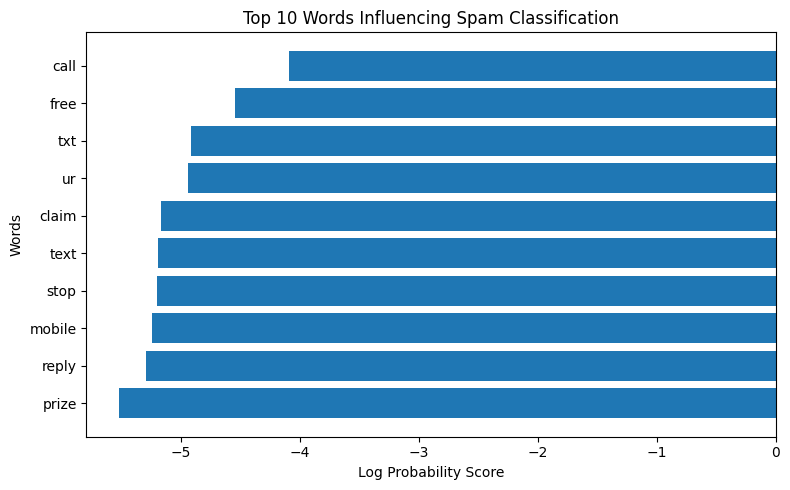

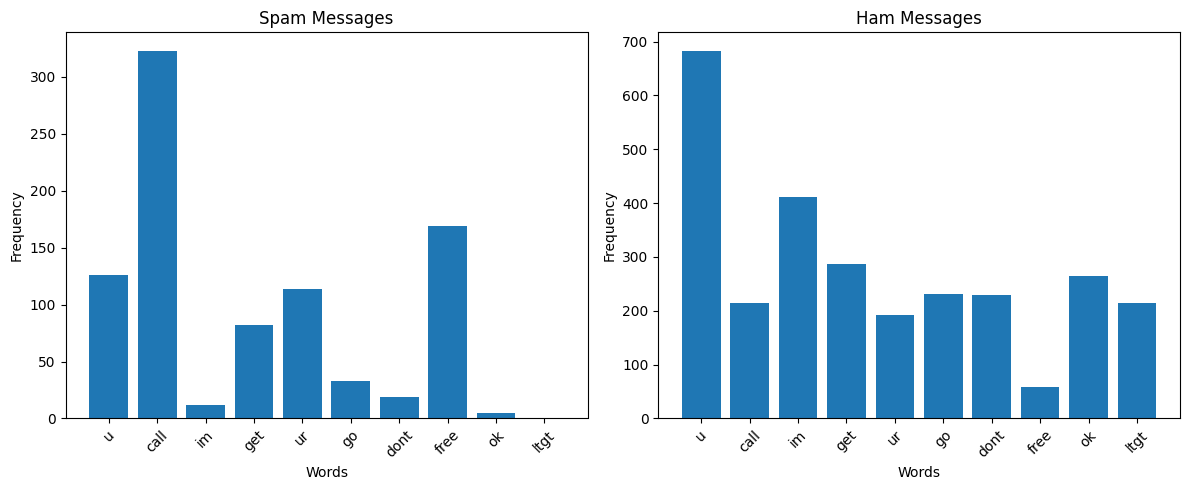

In [ ]:
print("SCENARIO 1 – MULTINOMIAL NAÏVE BAYES")
print("Name    : Priya Dharshini R")
print("Roll No : 24BAD092")

#  Import Required Libraries
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
#  Load Dataset
df = pd.read_csv(r"/content/sample_data/spam.csv", encoding='latin-1')

df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print("\nDataset Loaded Successfully")
print("Dataset Shape:", df.shape)
print("\nClass Distribution:\n", df['label'].value_counts())

#  Text Preprocessing
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_message'] = df['message'].apply(clean_text)

#  Convert Text to Numerical Features
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['clean_message'])

#  Encode Target Labels
encoder = LabelEncoder()
y = encoder.fit_transform(df['label'])

#. Train-Test Split
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train Multinomial Naïve Bayes Model
model = MultinomialNB(alpha=1.0)
model.fit(X_train, y_train)

#  Prediction
y_pred = model.predict(X_test)

#  Model Evaluation
print("\nMODEL PERFORMANCE")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

#  Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Misclassified Messages
test_df = df.loc[idx_test].copy()
test_df['Actual'] = y_test
test_df['Predicted'] = y_pred

misclassified = test_df[test_df['Actual'] != test_df['Predicted']]

print("\nSample Misclassified Messages:")
print(misclassified[['label','message']].head(10))

#  Laplace Smoothing Impact
model2 = MultinomialNB(alpha=0.1)
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)
print("\nAccuracy after alpha=0.1:",
      accuracy_score(y_test, y_pred2))
#  Feature Importance (Top 10 Spam Words)
feature_names = vectorizer.get_feature_names_out()
spam_log_probs = model.feature_log_prob_[1]
top_n = 10
top_indices = np.argsort(spam_log_probs)[-top_n:]
top_words = feature_names[top_indices]
top_scores = spam_log_probs[top_indices]
plt.figure(figsize=(8,5))
plt.barh(top_words, top_scores)
plt.xlabel("Log Probability Score")
plt.ylabel("Words")
plt.title("Top 10 Words Influencing Spam Classification")
plt.tight_layout()
plt.show()
# Word Frequency Comparison (Spam vs Ham)

# Find Top Words
all_words = " ".join(df['clean_message'])

top_words = pd.Series(all_words.split()) \
            .value_counts() \
            .head(10) \
            .index
# Count Spam Words
spam_counts = []
for word in top_words:
    spam_counts.append(
        df[df['label']=='spam']['clean_message']
        .str.contains(r'\b'+word+r'\b')
        .sum()
    )
# Count Ham Words
ham_counts = []
for word in top_words:
    ham_counts.append(
        df[df['label']=='ham']['clean_message']
        .str.contains(r'\b'+word+r'\b')
        .sum()
    )
# Plot in Same Image
plt.figure(figsize=(12,5))
# Graph 1 - Spam
plt.subplot(1,2,1)
plt.bar(top_words,spam_counts)
plt.xticks(rotation=45)
plt.title("Spam Messages")
plt.xlabel("Words")
plt.ylabel("Frequency")
# Graph 2 - Ham
plt.subplot(1,2,2)
plt.bar(top_words,ham_counts)
plt.xticks(rotation=45)
plt.title("Ham Messages")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()












**CODE EXPLANATION**

 **Step 1 – Import Required Libraries**

The required Python libraries are imported.

- pandas and numpy → Used for data handling
- re and string → Used for text cleaning
- matplotlib and seaborn → Used for visualization
- sklearn → Used for machine learning
- nltk → Used for stopword removal

Stopwords are downloaded using:

nltk.download('stopwords')

Stopwords are common words like:

the, is, and, are

These words do not help classification.

**Step 2 – Load Dataset**

The SMS Spam dataset is loaded using pandas.

Dataset contains:

• v1 → Label (Spam/Ham)  
• v2 → Message Text

Columns are renamed as:

• label  
• message

Dataset shape and class distribution are displayed.

**Step 3 – Text Preprocessing**

Text messages are cleaned before training.

Cleaning steps:

1. Convert text into lowercase

Example:

HELLO → hello

2. Remove numbers

Example:

win 100 → win

3. Remove punctuation

Example:

hello! → hello

4. Remove stopwords

Example:

This is a message → message

Clean messages are stored in:

clean_message column

**Step 4 – Convert Text into Numerical Features**

Machine learning works with numbers.

Text is converted into numbers using:

CountVectorizer

Example:

"win money now"

becomes:

win = 1  
money = 1  
now = 1

This process is called Vectorization.


**Step 5 – Encode Target Labels**

Labels must be converted into numbers.

Ham → 0  
Spam → 1

This is done using:

LabelEncoder


**Step 6 – Train-Test Split**

Dataset is divided into:

• Training Data → 80%

• Testing Data → 20%

Training data is used to train the model.

Testing data is used to test the model.

**Step 7 – Train Multinomial Naïve Bayes Model**

Multinomial Naïve Bayes model is created.

Alpha = 1.0

Alpha is Laplace smoothing.

Model is trained using:

model.fit()

**Step 8 – Prediction**

The trained model predicts message type.

Output:

• Spam or  Ham

Prediction is done using:

model.predict()

**Step 9 – Model Evaluation**

Model performance is measured using:

• Accuracy Shows total correct predictions.

• Precision Shows correct spam predictions.

• Recall Shows detected spam messages.

• F1 Score Balanced measure of precision and recall.

**Step 10 – Confusion Matrix**

Confusion matrix shows:

• Correct predictions

• Incorrect predictions

Displayed using heatmap.

**Step 11 – Misclassified Messages**

Messages predicted incorrectly are displayed.

This helps understand model errors.

**Step 12 – Laplace Smoothing**

Laplace smoothing avoids zero probability.

Two models are compared:

Alpha = 1.0

Alpha = 0.1

Accuracy values are compared.

**Step 13 – Feature Importance**

Top 10 spam words are displayed.

These words strongly indicate spam.

Example:

• free

• win

• prize

Graph is plotted using bar chart.

 **Step 14 – Word Frequency Comparison**

Top 10 words are selected.

Word frequency is calculated for:

• Spam Messages

• Ham Messages

**Two graphs are shown:**

Left Side → Spam Words

Right Side → Ham Words

This helps compare word usage.

 **Final Result**

The Multinomial Naïve Bayes model successfully classifies SMS messages into:

• Spam

• Ham

**Visualizations include:**

• Confusion Matrix

• Feature Importance Graph

• Word Frequency Comparison Graph

-----------------------------------------------------------------------------------

**SCENARIO 2 – GAUSSIAN NAÏVE BAYES**

**Problem Statement**\
Classify flower species based on physical measurements.

Dataset
Iris Dataset (sklearn)

Target Variable
Flower Species

Input Features
• Sepal Length
• Sepal Width
• Petal Length
• Petal Width

**IN-LAB TASKS**

1. Import required Python libraries.

2. Load the Iris dataset.

3. Perform data inspection & preprocessing.

4. Apply feature scaling.

5. Split dataset into training and testing sets.

6. Train Gaussian Naïve Bayes classifier.

7. Predict species labels.

8. Evaluate performance using:
   • Accuracy
   • Precision
   • Recall
   • F1 Score

9. Compare predictions with actual labels.

10. Analyze class probabilities.

11. Compare Gaussian NB with Logistic Regression (optional).

**Visualizations**

• Decision Boundary Plot (using two features)

• Confusion Matrix

• Probability Distribution Plots


Name: Priya Dharshini R
Register Number: 24BAD092
Scenario 2 – Gaussian Naïve Bayes (Iris Dataset)

Class Labels: ['setosa' 'versicolor' 'virginica']

First 5 Rows of Dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  

Dataset Shape: (150, 5)

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64

Model Evaluation:
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score 

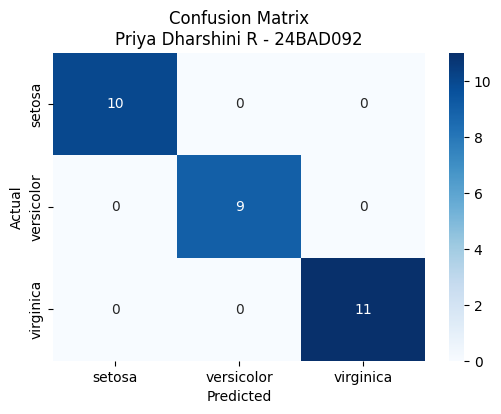

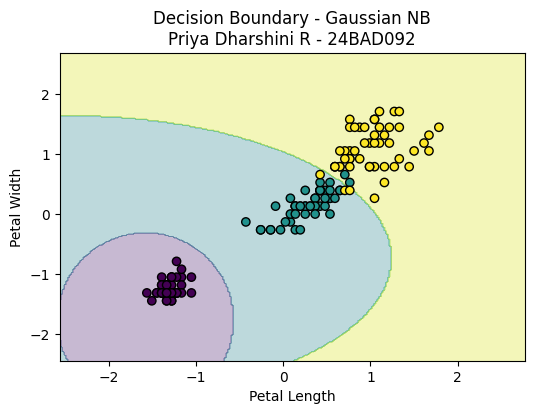

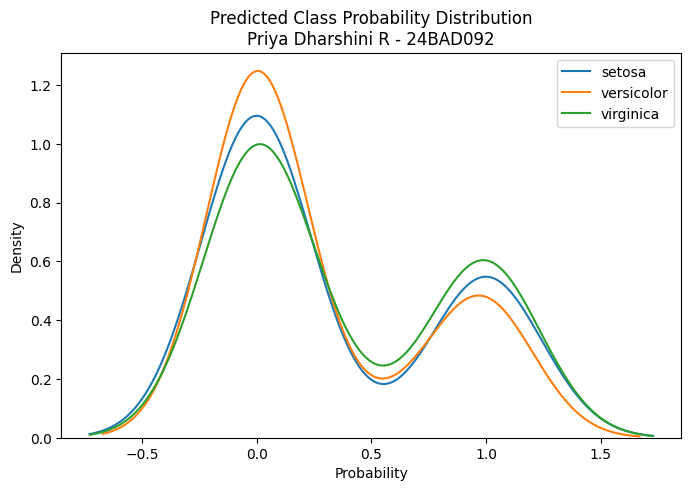


Logistic Regression Accuracy: 1.0

Program Completed Successfully!


In [ ]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Name: Priya Dharshini R")
print("Register Number: 24BAD092")
print("Scenario 2 – Gaussian Naïve Bayes (Iris Dataset)")


# Step 2: Load Dataset
iris = load_iris()
X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print("\nClass Labels:", target_names)

df = pd.DataFrame(X, columns=feature_names)
df['Species'] = y

print("\nFirst 5 Rows of Dataset:")
print(df.head())


# Step 3: Data Inspection
print("\nDataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())


# Step 4: Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


# Step 6: Train Gaussian Naïve Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)


# Step 7: Prediction
y_pred = gnb.predict(X_test)


# Step 8: Evaluation
print("\nModel Evaluation:")
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))


# Step 9: Compare Predictions
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print("\nActual vs Predicted (First 10 Rows):")
print(comparison.head(10))


# Step 10: Class Probabilities
probs = gnb.predict_proba(X_test)
prob_df = pd.DataFrame(probs, columns=target_names)

print("\nClass Probabilities (First 5 Rows):")
print(prob_df.head())

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix\nPriya Dharshini R - 24BAD092")
plt.show()


# Decision Boundary (Using Petal Length & Petal Width)

X_2 = X_scaled[:, 2:4]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_2, y, test_size=0.2, random_state=42
)

model2 = GaussianNB()
model2.fit(X_train2, y_train2)

x_min, x_max = X_2[:, 0].min() - 1, X_2[:, 0].max() + 1
y_min, y_max = X_2[:, 1].min() - 1, X_2[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = model2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,4))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_2[:, 0], X_2[:, 1], c=y, edgecolor='k')
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Decision Boundary - Gaussian NB\nPriya Dharshini R - 24BAD092")
plt.show()



# Predicted Class Probability Distribution (Smooth KDE)


plt.figure(figsize=(8,5))

sns.kdeplot(prob_df['setosa'], label='setosa')
sns.kdeplot(prob_df['versicolor'], label='versicolor')
sns.kdeplot(prob_df['virginica'], label='virginica')

plt.xlabel("Probability")
plt.ylabel("Density")
plt.title("Predicted Class Probability Distribution\nPriya Dharshini R - 24BAD092")
plt.legend()
plt.show()


# Optional: Compare with Logistic Regression


lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("\nLogistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("\nProgram Completed Successfully!")



**CODE EXPLANATION**

**Step 1 – Import Libraries**
The required Python libraries are imported.

* **NumPy** and **Pandas** are used for data handling.
* **Matplotlib** and **Seaborn** are used for visualization.
* **Scikit-learn** libraries are used for machine learning.

**Step 2 – Load Dataset**
The Iris dataset is loaded using sklearn.
Input features:

* Sepal Length
* Sepal Width
* Petal Length
* Petal Width

Target variable:

* Flower Species

The dataset is converted into a table format using Pandas.

**Step 3 – Data Inspection**
The dataset is checked for:

* Shape of dataset
* Missing values
* First few rows

This helps to understand the dataset.

**Step 4 – Feature Scaling**
StandardScaler is used to normalize the feature values.

Scaling helps improve model performance.

**Step 5 – Train-Test Split**
The dataset is divided into:

* Training data (80%)
* Testing data (20%)

Training data is used to train the model.
Testing data is used to test the model.

**Step 6 – Train Gaussian Naïve Bayes Model**
Gaussian Naïve Bayes classifier is trained using training data.

The model learns patterns between features and flower species.

**Step 7 – Prediction**
The trained model predicts flower species for test data.

Predicted values are stored in y_pred.

**Step 8 – Model Evaluation**
The model performance is measured using:

Accuracy
Shows overall correctness.

Precision
Shows correct positive predictions.

Recall
Shows how many actual values were predicted correctly.

F1 Score
Balance between precision and recall.

**Step 9 – Compare Predictions**
Actual values and predicted values are compared.

This helps to see model correctness.

**Step 10 – Class Probabilities**
The model calculates probability of each class.

Example:

* Setosa probability
* Versicolor probability
* Virginica probability

Higher probability means stronger prediction.

**Step 11 – Confusion Matrix**
Confusion matrix shows:

* Correct predictions
* Wrong predictions

It is displayed using heatmap.

**Step 12 – Decision Boundary Plot**
Decision boundary shows how the model separates classes.

Two features are used:

* Petal Length
* Petal Width

Different colors represent different species.

**Step 13 – Probability Distribution Plot**
Probability distributions are plotted.

This shows prediction confidence.

Smooth curves represent class probabilities.

**Step 14 – Logistic Regression Comparison**
Logistic Regression model is trained.

Accuracy is compared with Gaussian Naïve Bayes.

This helps evaluate model performance.

**Final Step**\
The program prints a completion message.
